In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

Data IMPORT

In [61]:
df = pd.read_excel('Online Retail.xlsx', parse_dates=['InvoiceDate'])
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [62]:
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print(df['Country'].value_counts().head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

=== Missing Values ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE   

# DATA Cleaning

In [63]:
print(f'Rows before cleaning: {len(df):,}')

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'After removing cancellations: {len(df):,}')

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(f'After removing negative/zero Quantity and UnitPrice: {len(df):,}')

df = df.dropna(subset=['CustomerID'])
print(f'After dropping missing CustomerID: {len(df):,}')

df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f'\nRevenue column created: min={df["Revenue"].min():.2f}, max={df["Revenue"].max():.2f}, mean={df["Revenue"].mean():.2f}')

Rows before cleaning: 541,909
After removing cancellations: 532,621
After removing negative/zero Quantity and UnitPrice: 530,104
After dropping missing CustomerID: 397,884

Revenue column created: min=0.00, max=168469.60, mean=22.40


In [64]:
df['Date'] = df['InvoiceDate'].dt.date
daily = df.groupby('Date').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Quantity=('Quantity', 'sum'),
    AvgOrderValue=('Revenue', 'mean')
).reset_index()

daily['Date'] = pd.to_datetime(daily['Date'])
daily = daily.sort_values('Date').reset_index(drop=True)

print(f'Daily time series: {len(daily)} days')
print(f'Date range: {daily["Date"].min().date()} to {daily["Date"].max().date()}')
daily.head(10)

Daily time series: 305 days
Date range: 2010-12-01 to 2011-12-09


,Date,Revenue,Orders,Quantity,AvgOrderValue
0,2010-12-01,46376.49,121,24215,23.880788
1,2010-12-02,47316.53,137,31142,23.658265
2,2010-12-03,23921.71,57,11839,21.687860
3,2010-12-05,31771.60,87,16449,11.736830
4,2010-12-06,31215.64,94,16291,16.049172
5,2010-12-07,53795.31,71,19444,48.464243
6,2010-12-08,39248.82,111,21573,20.148265
7,2010-12-09,38231.90,98,17415,21.859291
8,2010-12-10,33650.28,72,16051,24.384261
9,2010-12-12,17305.77,43,10599,12.051372


# EDA

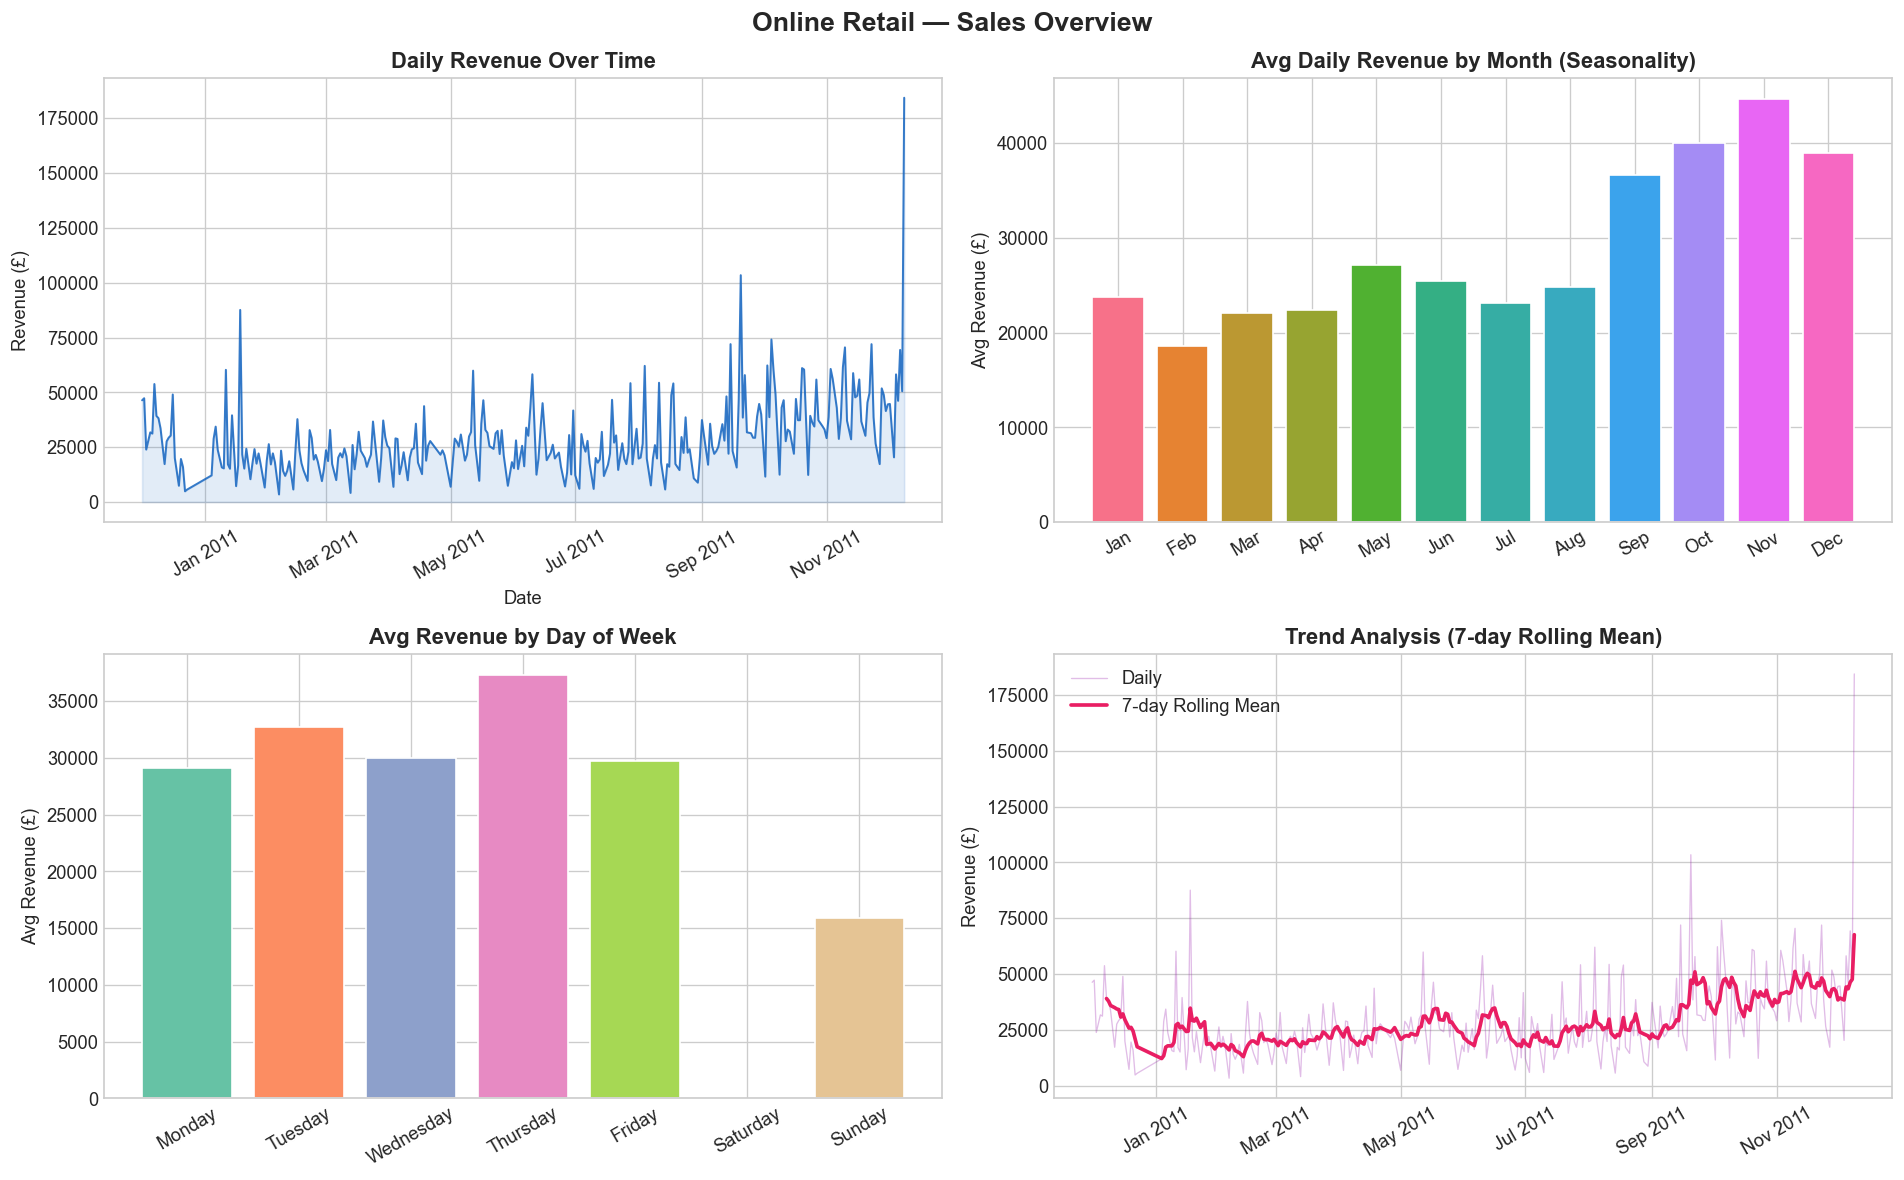

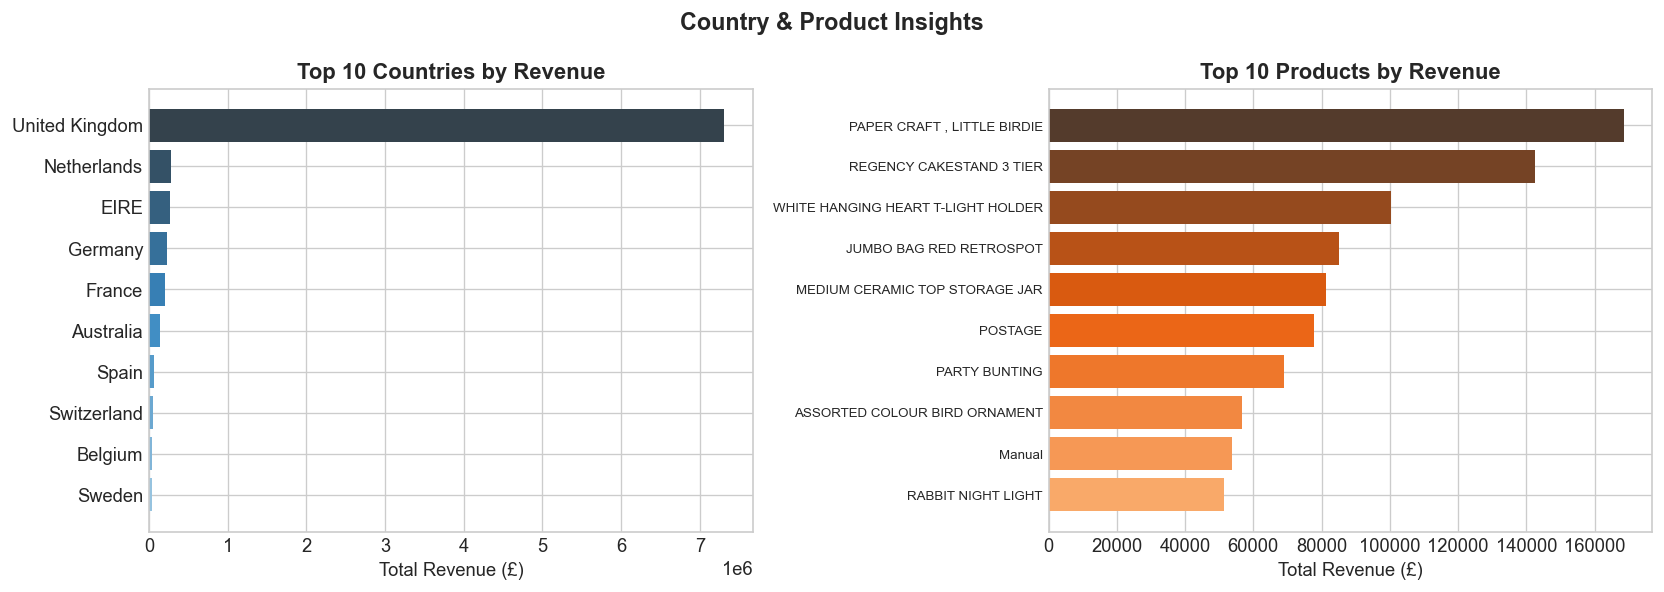

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Online Retail — Sales Overview', fontsize=16, fontweight='bold')

axes[0, 0].plot(daily['Date'], daily['Revenue'], color='#1565C0', linewidth=1.2, alpha=0.85)
axes[0, 0].fill_between(daily['Date'], daily['Revenue'], alpha=0.12, color='#1565C0')
axes[0, 0].set_title('Daily Revenue Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Revenue (£)')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=30)

daily['Month'] = daily['Date'].dt.month
monthly_rev = daily.groupby('Month')['Revenue'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors_m = sns.color_palette('husl', 12)
axes[0, 1].bar([month_names[m-1] for m in monthly_rev.index], monthly_rev.values, color=colors_m, edgecolor='white')
axes[0, 1].set_title('Avg Daily Revenue by Month (Seasonality)', fontweight='bold')
axes[0, 1].set_ylabel('Avg Revenue (£)')
axes[0, 1].tick_params(axis='x', rotation=30)

daily['DayOfWeek'] = daily['Date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = daily.groupby('DayOfWeek')['Revenue'].mean().reindex(dow_order)
axes[1, 0].bar(dow_order, dow_rev.values, color=sns.color_palette('Set2', 7), edgecolor='white')
axes[1, 0].set_title('Avg Revenue by Day of Week', fontweight='bold')
axes[1, 0].set_ylabel('Avg Revenue (£)')
axes[1, 0].tick_params(axis='x', rotation=30)

rolling = daily['Revenue'].rolling(window=7).mean()
axes[1, 1].plot(daily['Date'], daily['Revenue'], alpha=0.3, color='#9C27B0', linewidth=0.8, label='Daily')
axes[1, 1].plot(daily['Date'], rolling, color='#E91E63', linewidth=2.2, label='7-day Rolling Mean')
axes[1, 1].set_title('Trend Analysis (7-day Rolling Mean)', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].set_ylabel('Revenue (£)')
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Country & Product Insights', fontsize=14, fontweight='bold')

top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1],
             color=sns.color_palette('Blues_d', 10))
axes[0].set_title('Top 10 Countries by Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)')

top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
axes[1].barh(top_products.index[::-1], top_products.values[::-1],
             color=sns.color_palette('Oranges_d', 10))
axes[1].set_title('Top 10 Products by Revenue', fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('country_product_insights.png', dpi=150, bbox_inches='tight')
plt.show()

# MODEL SELECTION

In [66]:
models = {
    'Ridge Regression': (Ridge(alpha=1.0), True),
    'Random Forest': (RandomForestRegressor(n_estimators=300, max_depth=12,
                                            min_samples_leaf=2, random_state=42, n_jobs=-1), False),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                    max_depth=5, subsample=0.8, random_state=42), False)
}

results = {}
predictions = {}

for name, (model, use_scaled) in models.items():
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc if use_scaled else X_test
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    pred = np.maximum(pred, 0)

    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / (y_test + 1e-9))) * 100

    results[name] = {'MAE': round(mae,2), 'RMSE': round(rmse,2),
                     'R2': round(r2,4), 'MAPE_%': round(mape,2)}
    predictions[name] = pred
    print(f'{name:<22} | MAE={mae:>9,.2f} | RMSE={rmse:>9,.2f} | R²={r2:.4f} | MAPE={mape:.2f}%')

results_df = pd.DataFrame(results).T
best_name = results_df['R2'].idxmax()
print(f'\n✅ Best Model: {best_name}')
results_df

Ridge Regression       | MAE= 8,501.33 | RMSE=10,008.88 | R²=0.8175 | MAPE=23.55%
Random Forest          | MAE= 5,395.56 | RMSE=14,730.58 | R²=0.6046 | MAPE=9.50%
Gradient Boosting      | MAE= 5,622.23 | RMSE=13,763.14 | R²=0.6548 | MAPE=10.66%

✅ Best Model: Ridge Regression


,MAE,RMSE,R2,MAPE_%
Ridge Regression,8501.33,10008.88,0.8175,23.55
Random Forest,5395.56,14730.58,0.6046,9.50
Gradient Boosting,5622.23,13763.14,0.6548,10.66


# PERFORMANCE COMPARISON

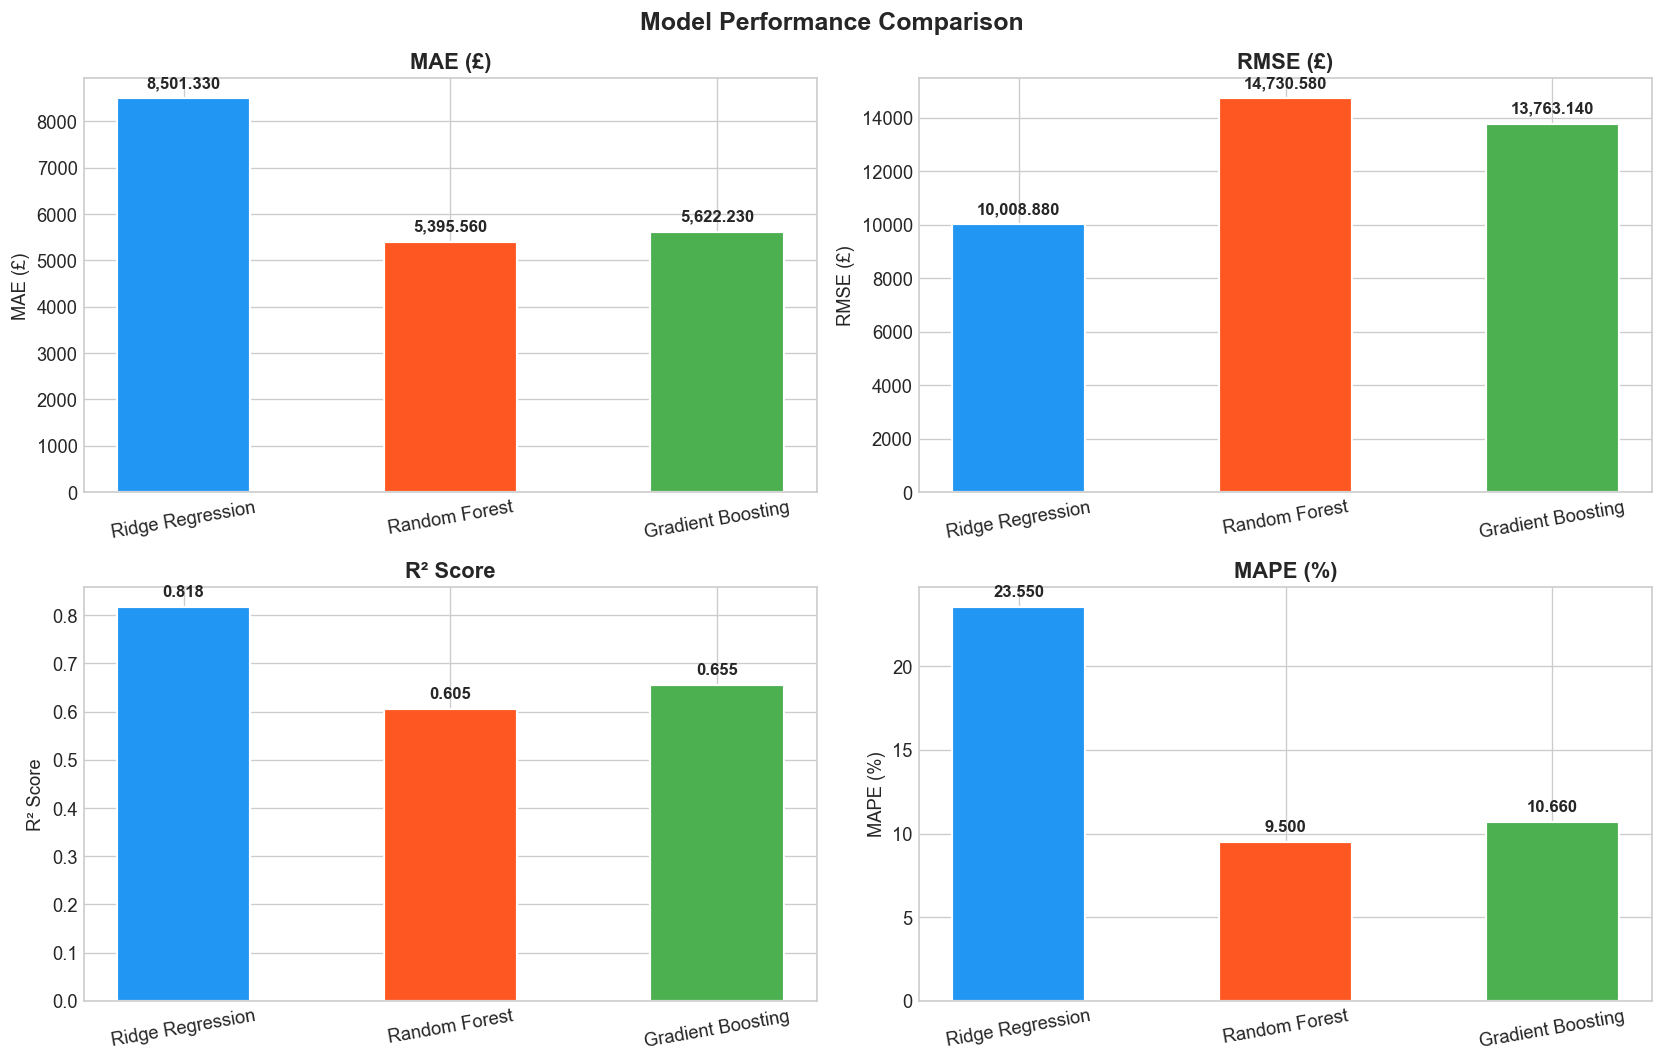

In [68]:
model_names = list(results.keys())
palette = ['#2196F3', '#FF5722', '#4CAF50']
metrics = ['MAE', 'RMSE', 'R2', 'MAPE_%']
metric_labels = ['MAE (£)', 'RMSE (£)', 'R² Score', 'MAPE (%)']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[i // 2][i % 2]
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=palette, edgecolor='white', linewidth=1.3, width=0.5)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{val:,.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticklabels(model_names, rotation=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ACTUAL VS PREDICTED

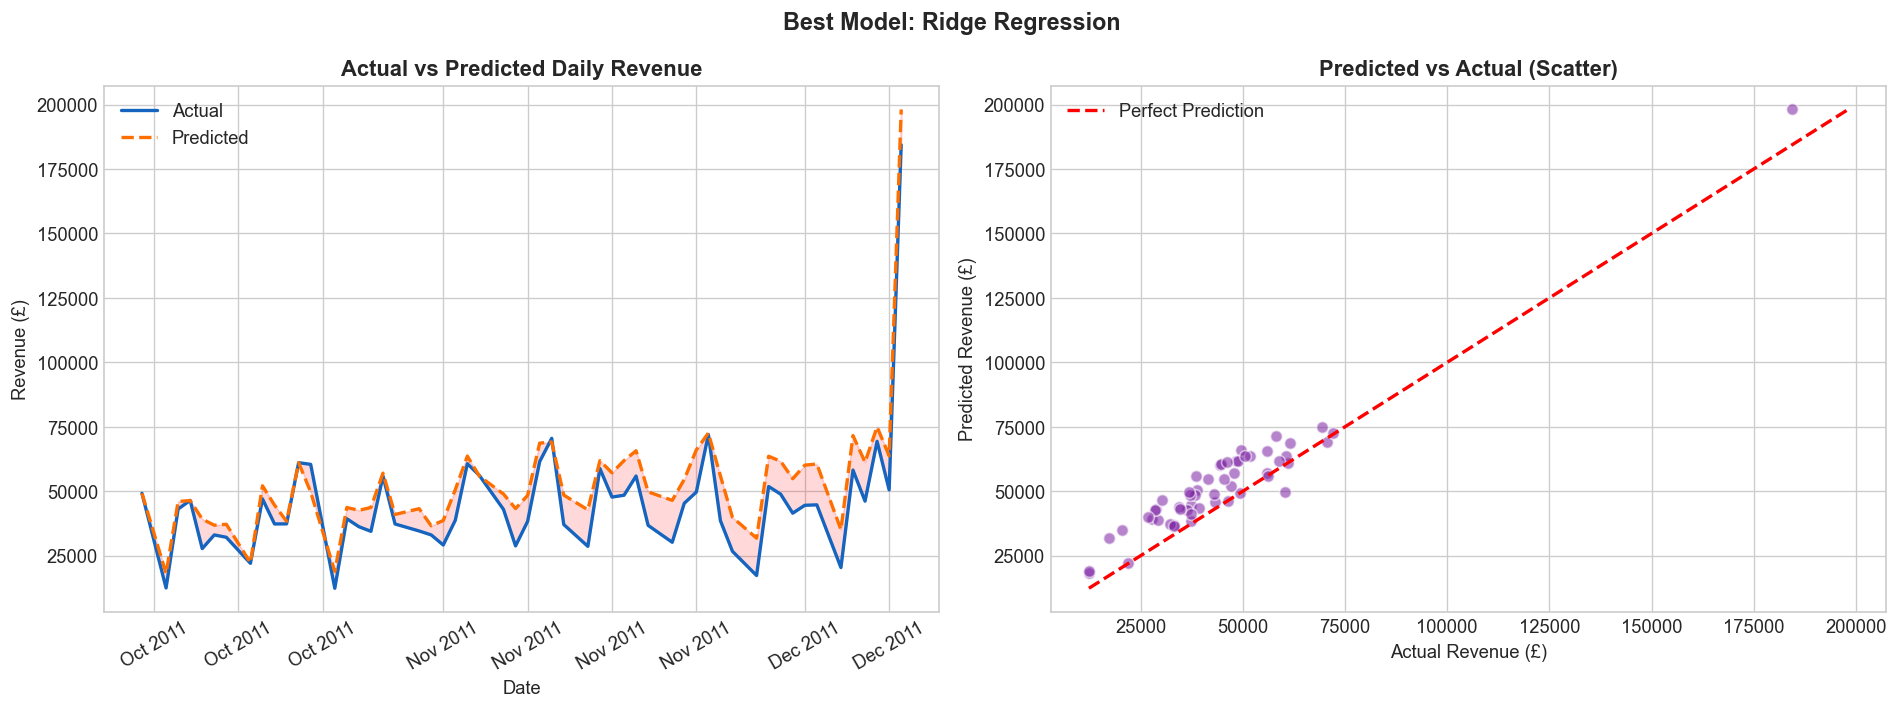

In [70]:
best_pred = predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Best Model: {best_name}', fontsize=14, fontweight='bold')

axes[0].plot(dates_test.values, y_test.values, label='Actual', color='#1565C0', linewidth=2)
axes[0].plot(dates_test.values, best_pred, label='Predicted', color='#FF6F00', linewidth=2, linestyle='--')
axes[0].fill_between(dates_test.values, y_test.values, best_pred, alpha=0.15, color='red')
axes[0].set_title('Actual vs Predicted Daily Revenue', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue (£)')
axes[0].legend(fontsize=11)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].scatter(y_test, best_pred, alpha=0.55, color='#7B1FA2', edgecolors='white', s=50)
mn = min(y_test.min(), best_pred.min())
mx = max(y_test.max(), best_pred.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title('Predicted vs Actual (Scatter)', fontweight='bold')
axes[1].set_xlabel('Actual Revenue (£)')
axes[1].set_ylabel('Predicted Revenue (£)')
axes[1].legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# RESIDUAL ANALYSIS

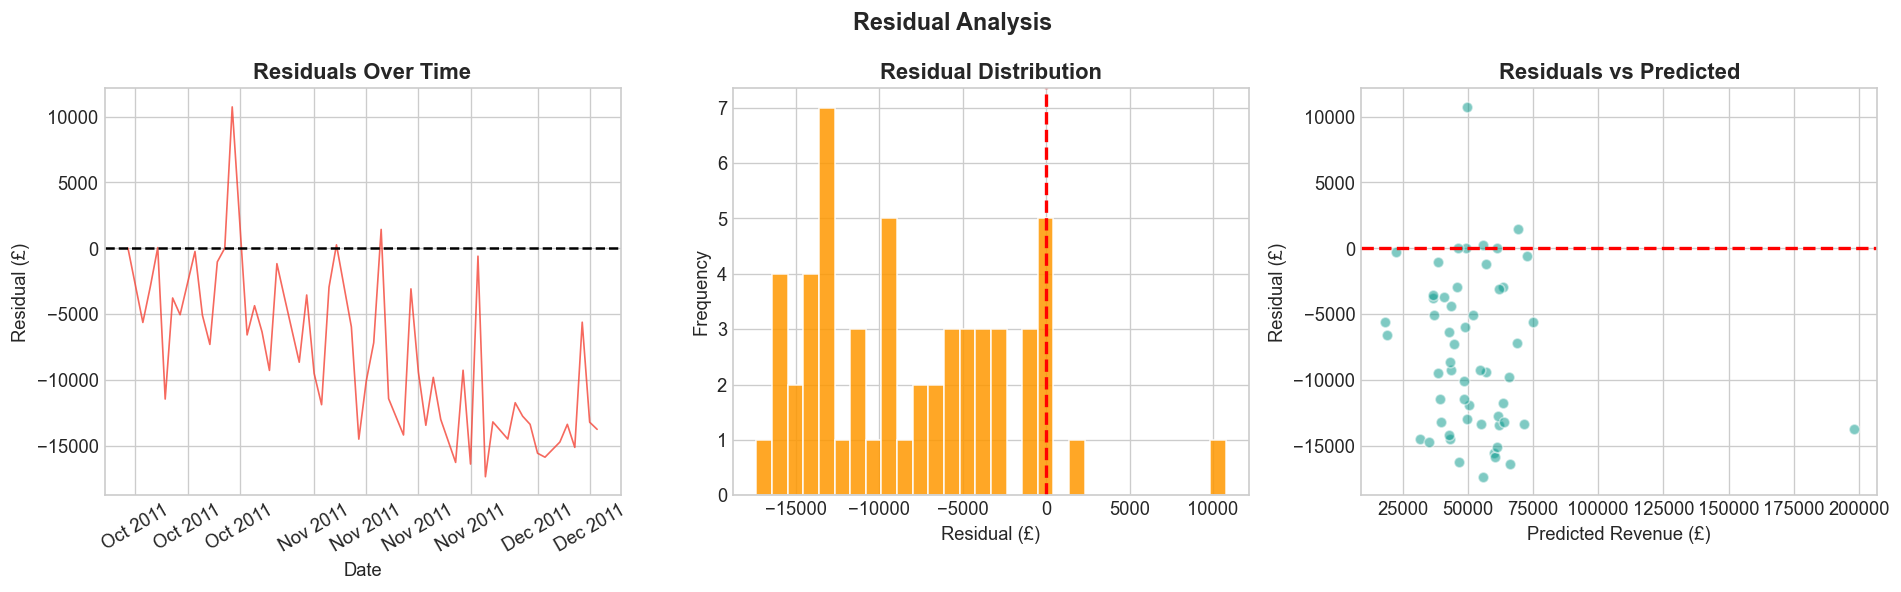

Mean residual : -8,045.65
Std residual  : 5,953.59


In [71]:
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Residual Analysis', fontsize=14, fontweight='bold')

axes[0].plot(dates_test.values, residuals, color='#F44336', linewidth=1, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals Over Time', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual (£)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].hist(residuals, bins=30, color='#FF9800', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (£)')
axes[1].set_ylabel('Frequency')

axes[2].scatter(best_pred, residuals, alpha=0.5, color='#009688', edgecolors='white', s=40)
axes[2].axhline(0, color='red', linewidth=2, linestyle='--')
axes[2].set_title('Residuals vs Predicted', fontweight='bold')
axes[2].set_xlabel('Predicted Revenue (£)')
axes[2].set_ylabel('Residual (£)')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean residual : {residuals.mean():,.2f}')
print(f'Std residual  : {residuals.std():,.2f}')

# 30 DAYS FORECAST

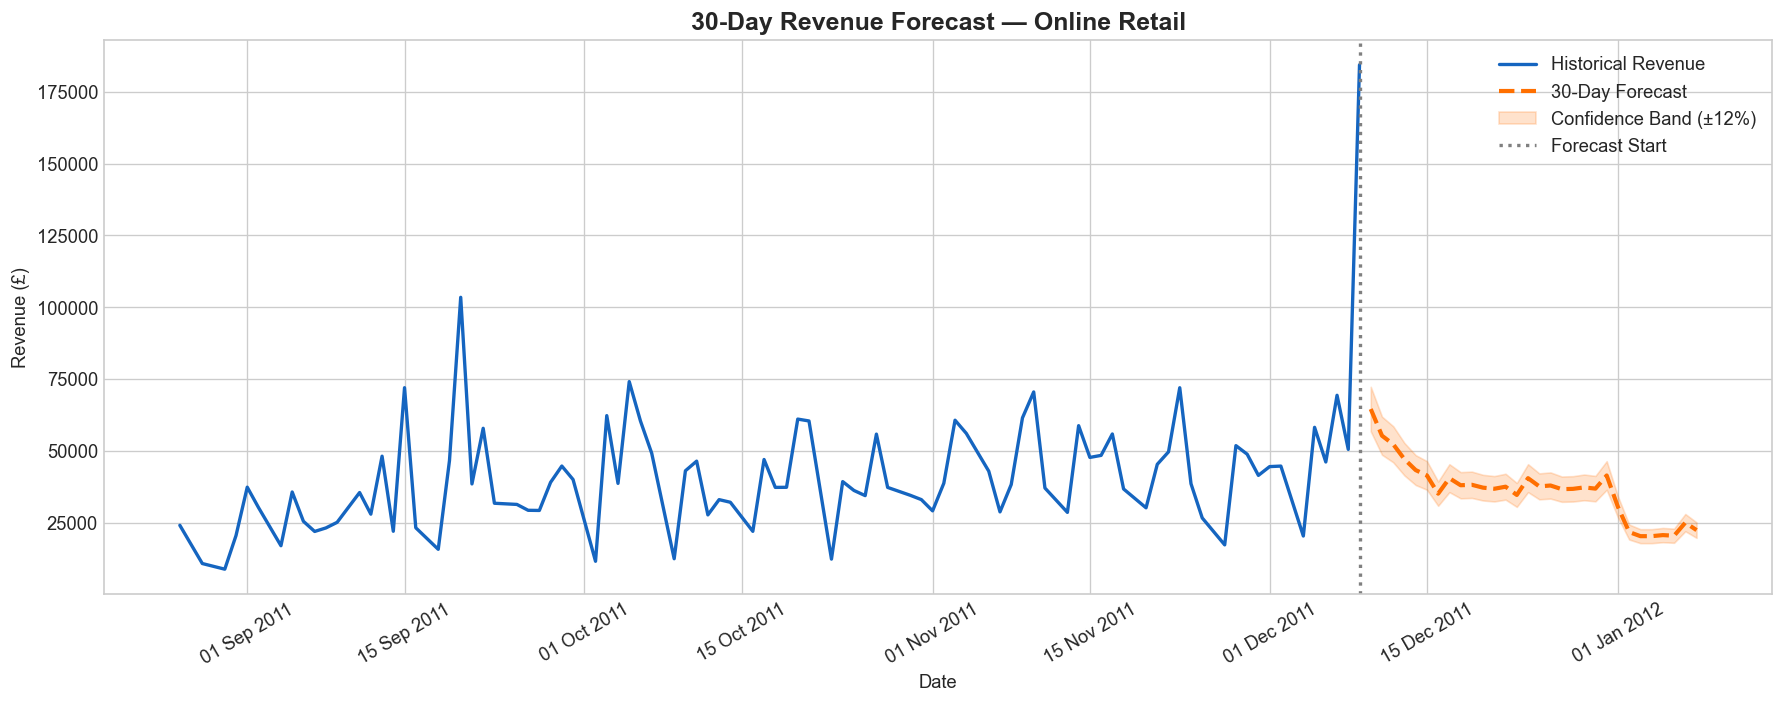

      Date  Forecasted_Revenue_GBP
2011-12-10                64564.27
2011-12-11                55288.15
2011-12-12                52306.52
2011-12-13                47096.97
2011-12-14                43320.92
2011-12-15                41464.52
2011-12-16                35114.90
2011-12-17                40502.19
2011-12-18                38046.13
2011-12-19                38206.13
2011-12-20                37199.34
2011-12-21                36822.52
2011-12-22                37540.87
2011-12-23                34670.33
2011-12-24                40507.89
2011-12-25                37653.31
2011-12-26                37955.06
2011-12-27                36682.81
2011-12-28                36787.47
2011-12-29                37301.47
2011-12-30                36871.58
2011-12-31                41441.97
2012-01-01                30530.32
2012-01-02                21767.27
2012-01-03                20325.88
2012-01-04                20322.74
2012-01-05                20697.83
2012-01-06          

In [73]:
forecast_days = 30
last_date = ts['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

future_revenue = []
history = ts['Revenue'].values.tolist()
history_orders = ts['Orders'].values.tolist()

for i, fdate in enumerate(future_dates):
    row = {
        'year': fdate.year,
        'month': fdate.month,
        'day': fdate.day,
        'day_of_week': fdate.dayofweek,
        'week_of_year': fdate.isocalendar().week,
        'quarter': fdate.quarter,
        'is_weekend': int(fdate.dayofweek >= 5),
        'is_month_start': int(fdate.is_month_start),
        'is_month_end': int(fdate.is_month_end),
        'month_sin': np.sin(2 * np.pi * fdate.month / 12),
        'month_cos': np.cos(2 * np.pi * fdate.month / 12),
        'dow_sin': np.sin(2 * np.pi * fdate.dayofweek / 7),
        'dow_cos': np.cos(2 * np.pi * fdate.dayofweek / 7),
        'week_sin': np.sin(2 * np.pi * fdate.isocalendar().week / 52),
        'week_cos': np.cos(2 * np.pi * fdate.isocalendar().week / 52),
        'lag_1': history[-1],
        'lag_7': history[-7] if len(history) >= 7 else np.mean(history),
        'lag_14': history[-14] if len(history) >= 14 else np.mean(history),
        'lag_30': history[-30] if len(history) >= 30 else np.mean(history),
        'rolling_mean_7': np.mean(history[-7:]),
        'rolling_mean_14': np.mean(history[-14:]),
        'rolling_mean_30': np.mean(history[-30:]),
        'rolling_std_7': np.std(history[-7:]),
        'rolling_max_7': np.max(history[-7:]),
        'rolling_min_7': np.min(history[-7:]),
        'orders_lag_1': history_orders[-1],
        'orders_rolling_7': np.mean(history_orders[-7:]),
        'Orders': np.mean(history_orders[-7:]),
        'Quantity': ts['Quantity'].mean(),
        'AvgOrderValue': ts['AvgOrderValue'].mean()
    }
    row_df = pd.DataFrame([row])[feature_cols]

    if best_name == 'Ridge Regression':
        pred_val = best_model_obj.predict(scaler.transform(row_df))[0]
    else:
        pred_val = best_model_obj.predict(row_df)[0]

    pred_val = max(pred_val, 0)
    future_revenue.append(pred_val)
    history.append(pred_val)
    history_orders.append(row['orders_lag_1'])

future_revenue = np.array(future_revenue)

fig, ax = plt.subplots(figsize=(15, 6))
hist_window = 90
hist_dates = ts['Date'].tail(hist_window)
hist_vals = ts['Revenue'].tail(hist_window)

ax.plot(hist_dates, hist_vals, color='#1565C0', linewidth=2, label='Historical Revenue')
ax.plot(future_dates, future_revenue, color='#FF6F00', linewidth=2.5, linestyle='--', label='30-Day Forecast')
ax.fill_between(future_dates, future_revenue * 0.88, future_revenue * 1.12,
                alpha=0.2, color='#FF6F00', label='Confidence Band (±12%)')
ax.axvline(last_date, color='gray', linestyle=':', linewidth=2, label='Forecast Start')
ax.set_title('30-Day Revenue Forecast — Online Retail', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('forecast_30day.png', dpi=150, bbox_inches='tight')
plt.show()

forecast_df = pd.DataFrame({'Date': future_dates, 'Forecasted_Revenue_GBP': np.round(future_revenue, 2)})
print(forecast_df.to_string(index=False))

# MONTHLY SUMMARY

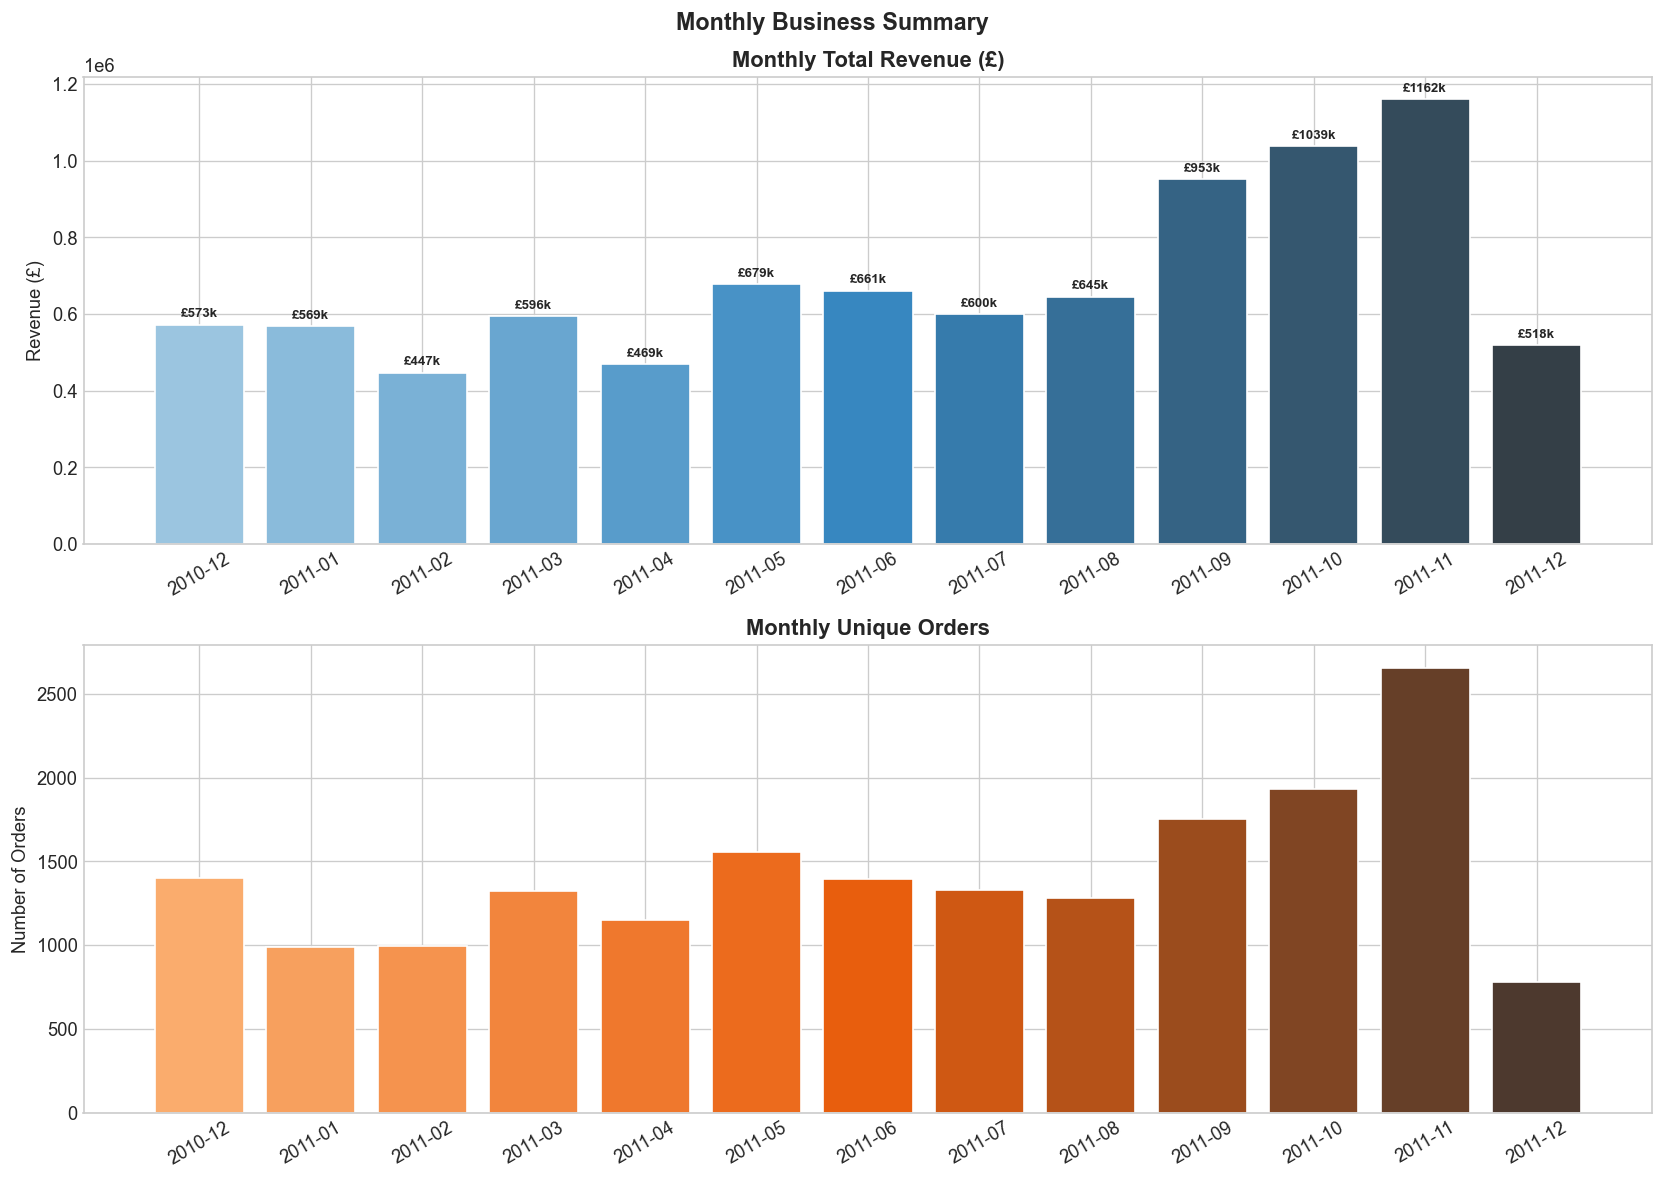

,YearMonth,Total_Revenue,Total_Orders,Total_Customers,Avg_Order_Value
0,2010-12,572713.89,1400,885,21.90
1,2011-01,569445.04,987,741,26.82
2,2011-02,447137.35,997,758,22.44
3,2011-03,595500.76,1321,974,21.91
4,2011-04,469200.36,1149,856,20.72
5,2011-05,678594.56,1555,1056,23.96
6,2011-06,661213.69,1393,991,24.32
7,2011-07,600091.01,1331,949,22.37
8,2011-08,645343.90,1280,935,23.90
9,2011-09,952838.38,1755,1266,23.80


In [75]:
monthly_summary = df.copy()
monthly_summary['YearMonth'] = monthly_summary['InvoiceDate'].dt.to_period('M')
monthly_report = monthly_summary.groupby('YearMonth').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique'),
    Total_Customers=('CustomerID', 'nunique'),
    Avg_Order_Value=('Revenue', 'mean')
).reset_index()
monthly_report['Total_Revenue'] = monthly_report['Total_Revenue'].round(2)
monthly_report['Avg_Order_Value'] = monthly_report['Avg_Order_Value'].round(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Monthly Business Summary', fontsize=14, fontweight='bold')

x_labels = monthly_report['YearMonth'].astype(str)
axes[0].bar(x_labels, monthly_report['Total_Revenue'], color=sns.color_palette('Blues_d', len(monthly_report)), edgecolor='white')
axes[0].set_title('Monthly Total Revenue (£)', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(monthly_report['Total_Revenue']):
    axes[0].text(i, v + monthly_report['Total_Revenue'].max()*0.01, f'£{v/1000:.0f}k',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[1].bar(x_labels, monthly_report['Total_Orders'], color=sns.color_palette('Oranges_d', len(monthly_report)), edgecolor='white')
axes[1].set_title('Monthly Unique Orders', fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('monthly_summary.png', dpi=150, bbox_inches='tight')
plt.show()
monthly_report